In [3]:
import pandas as pd

sessions = pd.read_csv('/Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_sessions.csv')
hits = pd.read_csv('/Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_hits.csv')

sessions.head(), hits.head()

/var/folders/q0/29fzx5zj31g3hxygfclyh8sr0000gn/T/ipykernel_53944/1544180933.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions = pd.read_csv('/Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_sessions.csv')


(                                  session_id          client_id  visit_date  \
 0  9055434745589932991.1637753792.1637753792  2108382700.163775  2021-11-24   
 1   905544597018549464.1636867290.1636867290   210838531.163687  2021-11-14   
 2  9055446045651783499.1640648526.1640648526  2108385331.164065  2021-12-28   
 3  9055447046360770272.1622255328.1622255328  2108385564.162225  2021-05-29   
 4  9055447046360770272.1622255345.1622255345  2108385564.162225  2021-05-29   
 
   visit_time  visit_number            utm_source utm_medium  \
 0   14:36:32             1  ZpYIoDJMcFzVoPFsHGJL     banner   
 1   08:21:30             1  MvfHsxITijuriZxsqZqt        cpm   
 2   02:42:06             1  ZpYIoDJMcFzVoPFsHGJL     banner   
 3   05:00:00             1  kjsLglQLzykiRbcDiGcD        cpc   
 4   05:00:00             2  kjsLglQLzykiRbcDiGcD        cpc   
 
            utm_campaign         utm_adcontent           utm_keyword  \
 0  LEoPHuyFvzoNfnzGgfcd  vCIpmpaGBnIQhyYNkXqp  puhZPIYqKXeF

In [4]:
sessions.info()
sessions.describe(include='all')

hits.info()
hits.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 828075 entries, 0 to 828

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
count,828075,828075,8.280750e+05,828075.000000,828075,36979,828075,828074,828074,369558,0.0
unique,306472,60,NaN,NaN,1,8441,66917,40,169,7657,NaN
top,3421843301545268943.1639295446.1639295446,2021-12-21,NaN,NaN,event,FwdMTcXzWAwhtsnMAbhS,podpiska.sberauto.com/,card_web,view_card,hAHqGICPFQiPwtzubOzs,NaN
freq,109,36230,NaN,NaN,828075,4830,149883,315230,151415,85038,NaN
mean,NaN,NaN,2.080475e+05,23.631452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.941239e+05,28.526628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000e+00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.646900e+04,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,9.213600e+04,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2.204440e+05,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
hits['event_action'].value_counts().head(50)

event_action
view_card                             151415
view_new_card                         149996
sub_landing                            98524
go_to_car_card                         44873
sub_view_cars_click                    41815
showed_number_ads                      40770
search_form_region                     33717
sap_search_form_cost_to                30029
search_form_search_btn                 29281
pagination_click                       26290
sap_search_form_cost_from              16953
search_form_model_select               16045
search_form_mark_select                15066
search_form_search_car_type_select     12721
view_more_click                        11154
photos_all                              8569
quiz_show                               7056
search_kpp                              5591
photos                                  4962
toggle_leasing_cars_show                3436
search_form_rental                      3397
listing_ads_sort                        33

#### Датасет содержит два уровня: сессии и события. Таблица ga_sessions описывает визит пользователя, а ga_hits — действия внутри визита. Большинство признаков категориальные, пропусков немного в некоторых полях, но event_value в ga_hits полностью пустой и не будет использоваться. По топу event_action видно, что основная активность пользователей связана с просмотром карточек, переходами по каталогу и поиском, поэтому для модели важны агрегаты поведения по сессии и маркетинговые признаки визита.

## Определяем таргет

In [8]:
target_actions = [
    'click_on_subscription',
]

hits['is_target'] = hits['event_action'].isin(target_actions).astype(int)

session_targets = (
    hits.groupby('session_id')['is_target']
    .max()
    .rename('target')
)

session_targets.value_counts(normalize=True)

target
0    0.993278
1    0.006722
Name: proportion, dtype: float64

#### Таргет сильно несбалансирован: доля положительного класса составляет 0.67%. Поэтому при обучении модели нельзя ориентироваться на accuracy; более корректно использовать ROC-AUC и методы компенсации дисбаланса классов, например class_weight='balanced'.

## агрегаты по сессиям

In [9]:
hits_agg = hits.groupby('session_id').agg(
    hits_count=('hit_number', 'max'),
    unique_pages=('hit_page_path', 'nunique'),
    target_hits=('is_target', 'sum')
).reset_index()

hits_agg['target_hits_share'] = hits_agg['target_hits'] / hits_agg['hits_count'].clip(lower=1)
hits_agg.head()

,session_id,hits_count,unique_pages,target_hits,target_hits_share
0,1000043953525145011.1638186424.1638186424,26,3,0,0.0
1,1000043953525145011.1638786530.1638786530,23,3,0,0.0
2,1000066343190736009.1639220433.1639220433,3,1,0,0.0
3,1000068705424463663.1640978223.1640978223,8,1,0,0.0
4,1000070419113613119.1638176575.1638176575,15,2,0,0.0


## объединение сессий и хитов

In [10]:
train_df = (
    sessions
    .merge(hits_agg, on='session_id', how='left')
    .merge(session_targets, on='session_id', how='left')
)

train_df['target'] = train_df['target'].fillna(0).astype(int)

train_df.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,hits_count,unique_pages,target_hits,target_hits_share,target
0,9055434745589932991.1637753792.1637753792,2108382700.163775,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,NaN,360x720,Chrome,Russia,Zlatoust,NaN,NaN,NaN,NaN,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,NaN,385x854,Samsung Internet,Russia,Moscow,NaN,NaN,NaN,NaN,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,NaN,360x720,Chrome,Russia,Krasnoyarsk,NaN,NaN,NaN,NaN,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,...,NaN,393x786,Chrome,Russia,Moscow,NaN,NaN,NaN,NaN,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,...,NaN,393x786,Chrome,Russia,Moscow,NaN,NaN,NaN,NaN,0


In [11]:
train_df.info()
train_df[['hits_count', 'unique_pages', 'target_hits_share', 'visit_number']].describe()
train_df['target'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 23 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   session_id                object 
 1   client_id                 object 
 2   visit_date                object 
 3   visit_time                object 
 4   visit_number              int64  
 5   utm_source                object 
 6   utm_medium                object 
 7   utm_campaign              object 
 8   utm_adcontent             object 
 9   utm_keyword               object 
 10  device_category           object 
 11  device_os                 object 
 12  device_brand              object 
 13  device_model              object 
 14  device_screen_resolution  object 
 15  device_browser            object 
 16  geo_country               object 
 17  geo_city                  object 
 18  hits_count                float64
 19  unique_pages              float64
 20  target_hits             

target
0    0.998909
1    0.001091
Name: proportion, dtype: float64

## заполнение пропусков 

In [12]:
train_df['hits_count'] = train_df['hits_count'].fillna(0)
train_df['unique_pages'] = train_df['unique_pages'].fillna(0)
train_df['target_hits'] = train_df['target_hits'].fillna(0)
train_df['target_hits_share'] = train_df['target_hits_share'].fillna(0)

cat_cols = [
    'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
    'utm_keyword', 'device_category', 'device_os', 'device_brand',
    'device_model', 'device_screen_resolution', 'device_browser',
    'geo_country', 'geo_city'
]

for col in cat_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna('unknown')

target сейчас крайне редкий, поэтому:

не стоит выкидывать строки только из-за пропусков в неключевых колонках;

лучше сохранять максимум данных и заполнять осмысленно.

Поэтому
Числовые пустоты после merge → 0.

Категориальные пустоты → 'unknown'.

Пустые даты/время → отдельно проверить долю и решить точечно.


In [13]:
train_df

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,hits_count,unique_pages,target_hits,target_hits_share,target
0,9055434745589932991.1637753792.1637753792,2108382700.163775,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,unknown,360x720,Chrome,Russia,Zlatoust,0.0,0.0,0.0,0.0,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,unknown,385x854,Samsung Internet,Russia,Moscow,0.0,0.0,0.0,0.0,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,unknown,360x720,Chrome,Russia,Krasnoyarsk,0.0,0.0,0.0,0.0,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,unknown,NOBKLgtuvqYWkXQHeYWM,unknown,...,unknown,393x786,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown,unknown,unknown,...,unknown,393x786,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.164016,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,unknown,unknown,VlqBmecIOXWjCWUmQkLd,...,unknown,1920x1080,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
1860038,9055421130527858185.1622007305.1622007305,2108379530.162201,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,unknown,...,unknown,390x844,Safari,Russia,Stavropol,0.0,0.0,0.0,0.0,0
1860039,9055422955903931195.1636979515.1636979515,2108379955.163698,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,unknown,375x667,Safari,Russia,Moscow,59.0,3.0,0.0,0.0,0
1860040,905543020766873816.1638189404.1638189404,210838164.163819,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,unknown,393x851,Chrome,Russia,Chelyabinsk,0.0,0.0,0.0,0.0,0


In [15]:
import sys
sys.path.append('src')

from data_prep import load_sessions_hits, build_training_table

sessions, hits = load_sessions_hits('data/ga_sessions.csv', 'data/ga_hits.csv')
train_df = build_training_table(sessions, hits)
train_df.head()

/Users/yaroslavbaev/Desktop/miphi/st_hakaton/src/data_prep.py:19: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions = pd.read_csv(sessions_path, sep=sep)
/Users/yaroslavbaev/Desktop/miphi/st_hakaton/src/data_prep.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['visit_time'] = pd.to_datetime(df['visit_time'], errors='coerce').dt.time


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,hits_count,unique_pages,target_hits,target_hits_share,target
0,9055434745589932991.1637753792.1637753792,2108382700.163775,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,unknown,360x720,Chrome,Russia,Zlatoust,0.0,0.0,0.0,0.0,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,unknown,385x854,Samsung Internet,Russia,Moscow,0.0,0.0,0.0,0.0,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,unknown,360x720,Chrome,Russia,Krasnoyarsk,0.0,0.0,0.0,0.0,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,unknown,NOBKLgtuvqYWkXQHeYWM,unknown,...,unknown,393x786,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown,unknown,unknown,...,unknown,393x786,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0


## Тесты

In [23]:
%%bash
python src/train_model.py \
  --sessions_path data/ga_sessions.csv \
  --hits_path data/ga_hits.csv \
  --models_dir models

Validation ROC-AUC: 0.9750
Model (pipeline) saved to models/model.pkl


Exception ignored in: <function ResourceTracker.__del__ at 0x106749bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10523dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
Exception ignored in: <function ResourceTracker.__del__ at 0x104d01bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessin

In [21]:
train_df

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,hits_count,unique_pages,target_hits,target_hits_share,target
0,9055434745589932991.1637753792.1637753792,2108382700.163775,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,unknown,360x720,Chrome,Russia,Zlatoust,0.0,0.0,0.0,0.0,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,unknown,385x854,Samsung Internet,Russia,Moscow,0.0,0.0,0.0,0.0,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,unknown,360x720,Chrome,Russia,Krasnoyarsk,0.0,0.0,0.0,0.0,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,unknown,NOBKLgtuvqYWkXQHeYWM,unknown,...,unknown,393x786,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown,unknown,unknown,...,unknown,393x786,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.164016,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,unknown,unknown,VlqBmecIOXWjCWUmQkLd,...,unknown,1920x1080,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
1860038,9055421130527858185.1622007305.1622007305,2108379530.162201,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,unknown,...,unknown,390x844,Safari,Russia,Stavropol,0.0,0.0,0.0,0.0,0
1860039,9055422955903931195.1636979515.1636979515,2108379955.163698,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,unknown,375x667,Safari,Russia,Moscow,59.0,3.0,0.0,0.0,0
1860040,905543020766873816.1638189404.1638189404,210838164.163819,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,unknown,393x851,Chrome,Russia,Chelyabinsk,0.0,0.0,0.0,0.0,0


In [29]:
neg_sample = train_df[train_df['target'] == 0].drop(columns=['session_id', 'client_id']).sample(5, random_state=42)
neg_sample.to_csv('sample_neg_infer.csv', index=False)
neg_sample.head()

,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,hits_count,unique_pages,target_hits,target_hits_share,target
1288725,2021-09-14,12:00:00,1,BHcvLfOaCWvWTykYqHVe,cpc,unknown,unknown,unknown,desktop,unknown,...,unknown,2560x1080,Chrome,Russia,Moscow,0.0,0.0,0.0,0.0,0
773772,2021-12-11,10:24:11,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,...,unknown,412x892,Chrome,Russia,Volzhskiy,0.0,0.0,0.0,0.0,0
258045,2021-09-29,15:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,gecBYcKZCPMcVYdSSzKP,JNHcPlZPxEMWDnRiyoBf,unknown,mobile,unknown,...,unknown,320x694,Chrome,Russia,Orenburg,0.0,0.0,0.0,0.0,0
97609,2021-09-11,17:00:00,1,MvfHsxITijuriZxsqZqt,blogger_channel,gVwpGdJDpteNmFIatPTG,JNHcPlZPxEMWDnRiyoBf,unknown,desktop,unknown,...,unknown,1920x1080,Chrome,Russia,Tyumen,0.0,0.0,0.0,0.0,0
827508,2021-12-27,21:34:36,1,ZpYIoDJMcFzVoPFsHGJL,banner,zxoiLxhuSIFrCeTLQVWZ,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,...,unknown,360x800,Chrome,Russia,Ivanovo,0.0,0.0,0.0,0.0,0


In [30]:
!python src/infer.py --model_path models/model.pkl --input_path sample_neg_infer.csv --input_format csv --threshold 0.5

   pred_label    pred_proba
0           0  6.349544e-08
1           0  6.980286e-04
2           0  1.253176e-08
3           0  6.722578e-08
4           0  3.601536e-04


In [27]:
pos_sample = train_df[train_df['target'] == 1].drop(columns=['session_id', 'client_id']).sample(5, random_state=42)
pos_sample.to_csv('sample_pos_infer.csv', index=False)
pos_sample.head()

,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,...,device_model,device_screen_resolution,device_browser,geo_country,geo_city,hits_count,unique_pages,target_hits,target_hits_share,target
1262872,2021-12-28,17:59:54,1,ZpYIoDJMcFzVoPFsHGJL,push,sbJRYgVfvcnqKJNDDYIr,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,...,unknown,375x785,Chrome,Russia,Moscow,25.0,3.0,1.0,0.040000,1
918025,2021-11-12,01:00:01,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,...,unknown,360x640,Chrome,Russia,Voronezh,38.0,1.0,1.0,0.026316,1
801068,2021-12-25,09:12:30,3,QxAxdyPLuQMEcrdZWdWb,cpc,unknown,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,...,unknown,428x926,Safari (in-app),Russia,Moscow,10.0,1.0,1.0,0.100000,1
1807844,2021-11-16,01:44:08,1,ZpYIoDJMcFzVoPFsHGJL,smartbanner,jqlUOdZBNZYfInQVcZlS,qhEmhjPXvwgEHdBikgEQ,puhZPIYqKXeFPaUviSjo,mobile,iOS,...,unknown,428x926,Safari,Russia,Moscow,20.0,2.0,1.0,0.050000,1
1191336,2021-11-08,22:07:49,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,...,unknown,320x640,Chrome,Russia,Samara,11.0,1.0,1.0,0.090909,1


In [28]:
!python src/infer.py --model_path models/model.pkl --input_path sample_pos_infer.csv --input_format csv --threshold 0.5

   pred_label  pred_proba
0           1    0.999640
1           1    0.999574
2           1    0.999926
3           1    0.999920
4           1    0.999698


## 1. Разведочный анализ данных (EDA)

### 1.1. Цель и контекст задачи

Мы анализируем сайт «СберАвтоподписка» — сервис долгосрочной аренды автомобилей.  
Цель проекта: создать модель, которая предсказывает вероятность того, что пользователь совершит **целевое действие** на сайте (оставит заявку, закажет звонок, откроет диалог и т.п.).

На основе этой модели компания сможет:
- Оценивать эффективность каналов привлечения трафика,
- Адаптировать рекламные кампании,
- Улучшать UX сайта за счёт анализа поведения пользователей.

**Целевое действие** (по глоссарию брифа):  
Любое ключевое событие на сайте:  
`ga_hits.event_action in [перечень ключей]`  
(Оставить заявку, Заказать звонок, Открыть диалог и др.).

В этом блоке мы:
- Прочитаем данные и изучим структуру,
- Оценим полноту, чистоту и типы данных,
- Построим графики распределений и корреляций,
- Добавим интерпретацию: какие связи мы наблюдаем и что это может означать для бизнеса.

### 1.2. Что будем исследовать

Мы работаем с двумя датасетами:

1. **ga_sessions.csv** (сессии) — 18ct 9к записей, 18 колонок:
   - `session_id`, `client_id`
   - `visit_date`, `visit_time`, `visit_number`
   - `utm_source`, `utm_medium`, `utm_campaign`, `utm_adcontent`, `utm_keyword`
   - `device_category`, `device_os`, `device_brand`, `device_model`, `device_screen_resolution`, `device_browser`
   - `geo_country`, `geo_city`

2. **ga_hits.csv** (хиты — пользовательские действия) — 828 тыс. записей, 11 колонок:
   - `session_id`, `hit_date`, `hit_time`
   - `hit_number`, `hit_type`, `hit_referer`
   - `hit_page_path`
   - `event_category`, `event_action`, `event_label`, `event_value`

В этом блоке EDA мы:
- Посмотрим `.head()`, `.info()`, `.describe(include='all')`,
- Оценим пропуски и типовые ошибки,
- Построим:
  - распределение таргета (если есть),
  - Гистограмы для ключевых числовых фич,
  - Столбчатую диаграум для ключевых категориальных фич,
  - Тепловую карту корреляций для числовых переменных,
- Напишем интерпретацию: что говорят нам эти данные с точки зрения бизнеса.

### 1.3 Код


/var/folders/q0/29fzx5zj31g3hxygfclyh8sr0000gn/T/ipykernel_43580/709140108.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions = pd.read_csv('/Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_sessions.csv')


                                  session_id          client_id  visit_date  \
0  9055434745589932991.1637753792.1637753792  2108382700.163775  2021-11-24   
1   905544597018549464.1636867290.1636867290   210838531.163687  2021-11-14   
2  9055446045651783499.1640648526.1640648526  2108385331.164065  2021-12-28   
3  9055447046360770272.1622255328.1622255328  2108385564.162225  2021-05-29   
4  9055447046360770272.1622255345.1622255345  2108385564.162225  2021-05-29   

  visit_time  visit_number            utm_source utm_medium  \
0   14:36:32             1  ZpYIoDJMcFzVoPFsHGJL     banner   
1   08:21:30             1  MvfHsxITijuriZxsqZqt        cpm   
2   02:42:06             1  ZpYIoDJMcFzVoPFsHGJL     banner   
3   05:00:00             1  kjsLglQLzykiRbcDiGcD        cpc   
4   05:00:00             2  kjsLglQLzykiRbcDiGcD        cpc   

           utm_campaign         utm_adcontent           utm_keyword  \
0  LEoPHuyFvzoNfnzGgfcd  vCIpmpaGBnIQhyYNkXqp  puhZPIYqKXeFPaUviSjo   
1  F

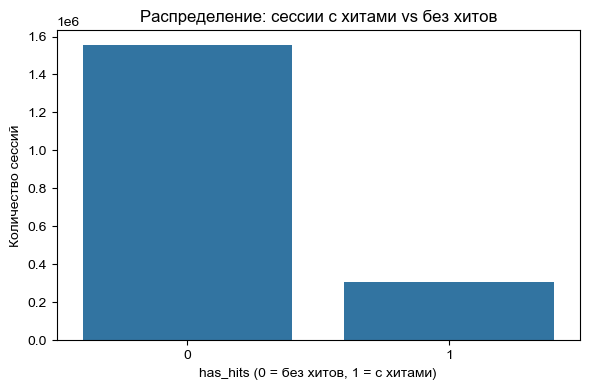

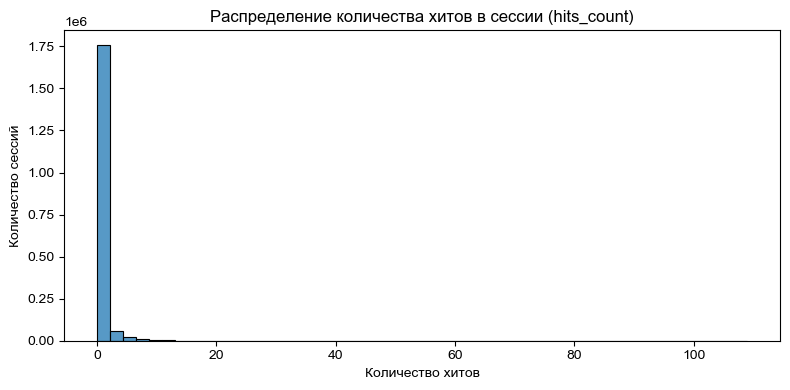

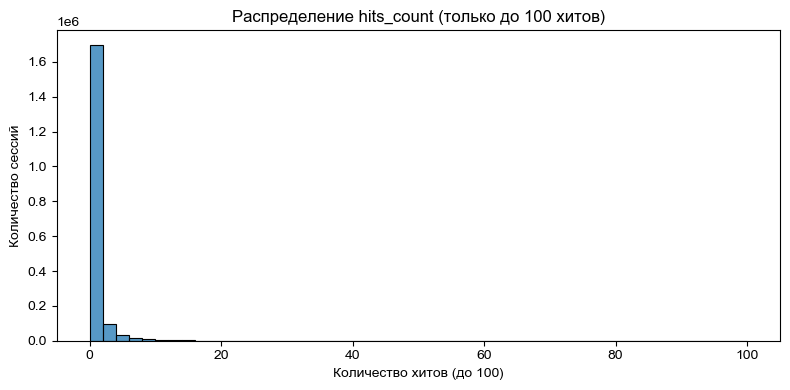

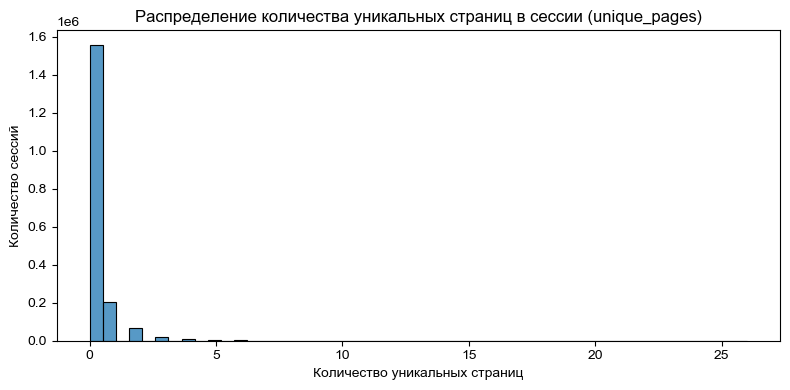

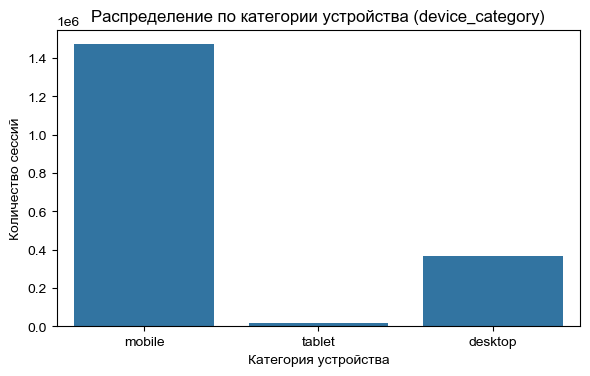

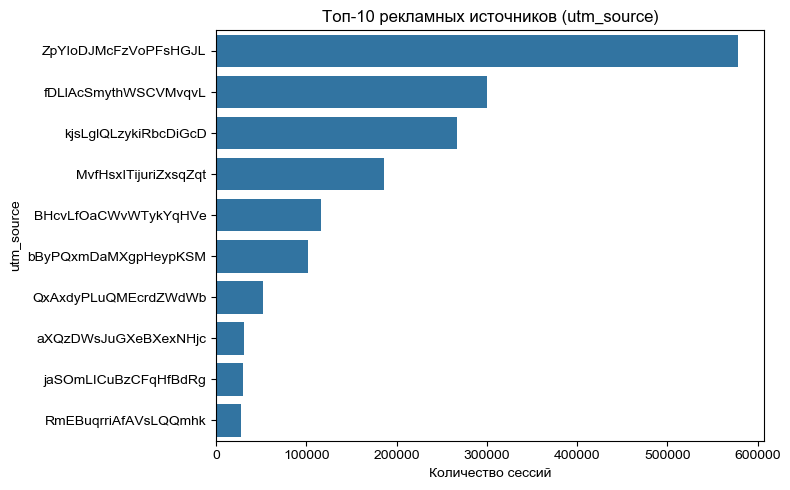

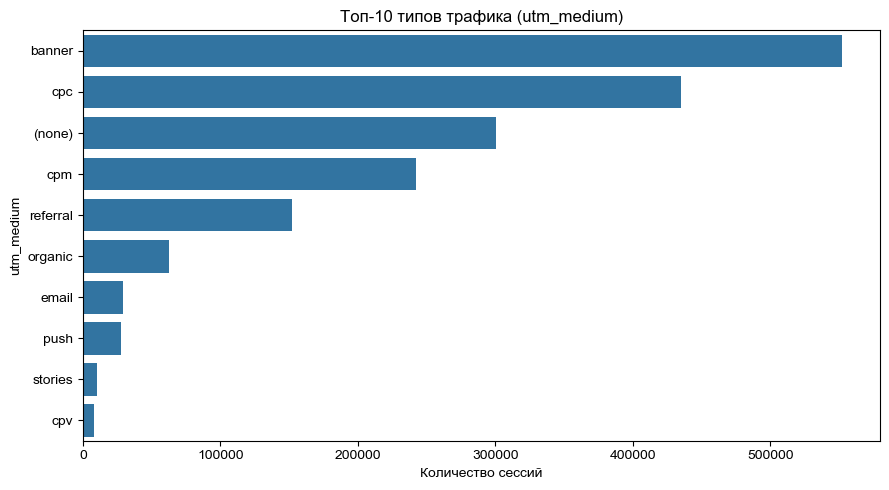


Количество сессий по utm_medium
utm_medium
banner             552272
cpc                434794
(none)             300575
cpm                242083
referral           152050
organic             63034
email               29240
push                28035
stories             10582
cpv                  8022
blogger_channel      8015
smartbanner          6794
blogger_stories      4312
cpa                  4279
tg                   4011
app                  2836
post                 2326
smm                  1985
outlook              1332
clicks                934
Name: count, dtype: int64


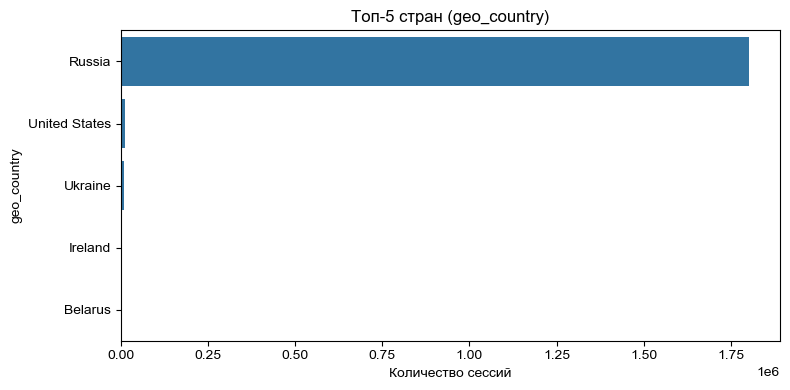


Количество сессий по странам
geo_country
Russia           1800565
United States      11784
Ukraine             9012
Ireland             4034
Belarus             3636
Sweden              2694
Kazakhstan          2279
Germany             2232
Turkey              1953
Netherlands         1549
Name: count, dtype: int64


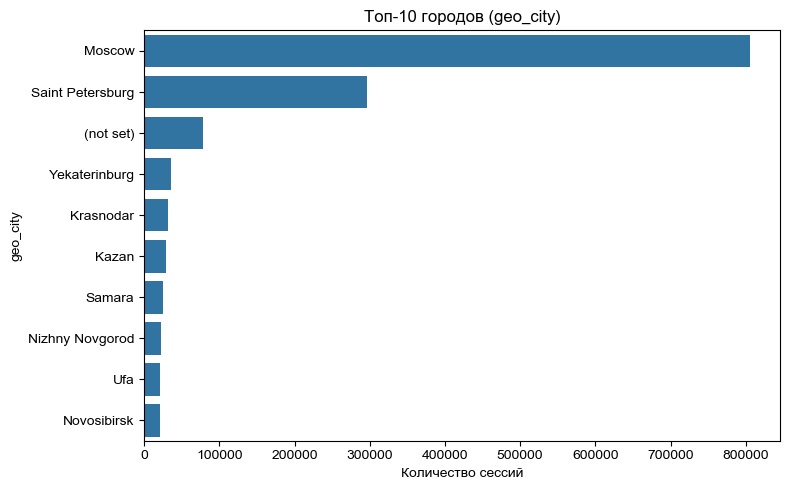

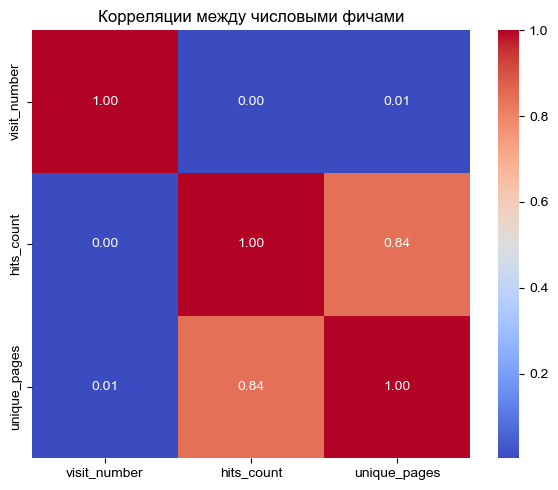


Конверсия по device_category
  device_category    total  with_hits        cr
0         desktop   366863      53907  0.146940
1          mobile  1474871     248928  0.168780
2          tablet    18308       2444  0.133494

Конверсия (CR) по utm_medium
           utm_medium   total  with_hits        cr
0              (none)  300575      28778  0.095743
1           (not set)     480        112  0.233333
2                 CPM      40         23  0.575000
3        Sbol_catalog       1          1  1.000000
4                 app    2836        297  0.104725
5             article      17          3  0.176471
6              banner  552272     140416  0.254252
7     blogger_channel    8015       1238  0.154460
8      blogger_header     771          0  0.000000
9     blogger_stories    4312        190  0.044063
10          catalogue       4          0  0.000000
11             cbaafe      47          0  0.000000
12             clicks     934        103  0.110278
13                cpa    4279     

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Вибраем русский язык для графиков
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans', 'Arial']

# Загружаем данные
sessions = pd.read_csv('/Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_sessions.csv')
hits = pd.read_csv('/Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_hits.csv')

# 1. Смотрим "верхний" уровень данных
print(sessions.head())
print(hits.head())

# 2. Типы и пропуски
sessions.info()
hits.info()

# 3. Описательная статистика (включая все типы)
print(sessions.describe(include='all'))
print(hits.describe(include='all'))

# 4. Процент пропусков по колонкам
sessions_missing = sessions.isna().mean() * 100
hits_missing = hits.isna().mean() * 100

print(sessions_missing)
print(hits_missing)

# 5. Для EDA: объединим сессии и хиты на уровне session_id
# Берём только ключевые колонки
sessions_eda = sessions[['session_id', 'client_id', 'visit_number',
                         'utm_source', 'utm_medium',
                         'device_category', 'geo_country', 'geo_city']]

# Агрегируем по session_id: количество хитов в сессии
hits_agg = hits.groupby('session_id').agg(
    hits_count=('hit_number', 'size'),
    unique_pages=('hit_page_path', 'nunique')
).reset_index()

# Соединяем
df = sessions_eda.merge(hits_agg, on='session_id', how='left')

# Если сессии без хитов (hits_count = NaN), заполняем 0
df['hits_count'] = df['hits_count'].fillna(0)
df['unique_pages'] = df['unique_pages'].fillna(0)

# 6. Для интерпретации: делаем бинарный маркер "есть ли хиты"
df['has_hits'] = (df['hits_count'] > 0).astype(int)

# 7. Визуализация: распределение has_hits (0/1)
plt.figure(figsize=(6, 4))
sns.countplot(x='has_hits', data=df)
plt.title('Распределение: сессии с хитами vs без хитов')
plt.xlabel('has_hits (0 = без хитов, 1 = с хитами)')
plt.ylabel('Количество сессий')
plt.tight_layout()
plt.show()

# 8. Histogram: hits_count (количество хитов в сессии)
plt.figure(figsize=(8, 4))
sns.histplot(df['hits_count'], bins=50, kde=False)
plt.title('Распределение количества хитов в сессии (hits_count)')
plt.xlabel('Количество хитов')
plt.ylabel('Количество сессий')
plt.tight_layout()
plt.show()

# 9. Histogram: hits_count с логарифмическим масштабом (для длинных хвостов)
plt.figure(figsize=(8, 4))
sns.histplot(df['hits_count'].clip(upper=100), bins=50, kde=False)
plt.title('Распределение hits_count (только до 100 хитов)')
plt.xlabel('Количество хитов (до 100)')
plt.ylabel('Количество сессий')
plt.tight_layout()
plt.show()

# 10. Histogram: unique_pages (количество уникальных страниц)
plt.figure(figsize=(8, 4))
sns.histplot(df['unique_pages'], bins=50, kde=False)
plt.title('Распределение количества уникальных страниц в сессии (unique_pages)')
plt.xlabel('Количество уникальных страниц')
plt.ylabel('Количество сессий')
plt.tight_layout()
plt.show()

# 11. Barplot: device_category (категория устройства)
plt.figure(figsize=(6, 4))
sns.countplot(x='device_category', data=df)
plt.title('Распределение по категории устройства (device_category)')
plt.xlabel('Категория устройства')
plt.ylabel('Количество сессий')
plt.tight_layout()
plt.show()

# 12. Barplot: top-10 utm_source (топ рекламных источников)
utm_source_top = df['utm_source'].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=utm_source_top.values, y=utm_source_top.index)
plt.title('Топ-10 рекламных источников (utm_source)')
plt.xlabel('Количество сессий')
plt.ylabel('utm_source')
plt.tight_layout()
plt.show()

# 13. Barplot: top-10 utm_medium (тип трафика)
medium_top = df['utm_medium'].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=medium_top.values, y=medium_top.index)
plt.title('Топ-10 типов трафика (utm_medium)')
plt.xlabel('Количество сессий')
plt.ylabel('utm_medium')
plt.tight_layout()
plt.show()

# И выводим таблицу
print("\nКоличество сессий по utm_medium")
print(df['utm_medium'].value_counts().head(20))

# 14. Barplot: geo_country (топ-5 стран)
# Если почти все Russia, то топ-5 покажет разницу

country_top = df['geo_country'].value_counts().head(5)

plt.figure(figsize=(8, 4))
sns.barplot(x=country_top.values, y=country_top.index)
plt.title('Топ-5 стран (geo_country)')
plt.xlabel('Количество сессий')
plt.ylabel('geo_country')
plt.tight_layout()
plt.show()

# И выводим таблицу
print("\nКоличество сессий по странам")
print(df['geo_country'].value_counts().head(10))

# 15. Барплот: geo_city (топ-10 городов)
city_top = df['geo_city'].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=city_top.values, y=city_top.index)
plt.title('Топ-10 городов (geo_city)')
plt.xlabel('Количество сессий')
plt.ylabel('geo_city')
plt.tight_layout()
plt.show()

# 16. Тепловая карта корреляций для числовых фич
num_cols = ['visit_number', 'hits_count', 'unique_pages']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляции между числовыми фичами')
plt.tight_layout()
plt.show()

# 17. Конверсия (CR) по device_category
cr_by_device = df.groupby('device_category').agg(
    total=('session_id', 'size'),
    with_hits=('has_hits', 'sum')
).reset_index()
cr_by_device['cr'] = cr_by_device['with_hits'] / cr_by_device['total']

print("\nКонверсия по device_category")
print(cr_by_device[['device_category', 'total', 'with_hits', 'cr']])

# 18. Конверсия (CR) по utm_medium (органический vs платный)
cr_by_medium = df.groupby('utm_medium').agg(
    total=('session_id', 'size'),
    with_hits=('has_hits', 'sum')
).reset_index()
cr_by_medium['cr'] = cr_by_medium['with_hits'] / cr_by_medium['total']

print("\nКонверсия (CR) по utm_medium")
print(cr_by_medium[['utm_medium', 'total', 'with_hits', 'cr']])

# 19. Конверсия (CR) по топ-5 utm_source
cr_by_source = df.groupby('utm_source').agg(
    total=('session_id', 'size'),
    with_hits=('has_hits', 'sum')
).reset_index()
cr_by_source['cr'] = cr_by_source['with_hits'] / cr_by_source['total']
cr_by_source_top = cr_by_source.sort_values('cr', ascending=False).head(10)

print("\nКонверсия по топ-10 utm_source")
print(cr_by_source_top[['utm_source', 'total', 'with_hits', 'cr']])

## 2. Выводы. Разведочный анализ данных (EDA)

### 2.1. Общая структура данных и пропуски

**sessions (сессии):**
- 1.86 млн записей, 18 колонок: 1 `int64` (visit_number), 17 `object`.
- Пропуски:
  - `utm_source`: 0.005%
  - `utm_campaign`: 11.8%
  - `utm_adcontent`: 18%
  - `utm_keyword`: 58.2%
  - `device_os`: 57.5%
  - `device_brand`: 19.7%
  - `device_model`: 99.1% (почти нет)

**hits (хиты):**
- 828 тыс. записей, 11 колонок: 2 `float64`, 1 `int64`, 8 `object`.
- Пропуски:
  - `hit_referer`: 95.5% (почти нет)
  - `event_value`: 100% (все нулевые)
  - `event_label`: 55.4%
  - `event_category` и `event_action`: почти полного нет (0.0001%)

**Вывод:**
Сессий ~2.2× больше, чем хитов. Это показывает, что большинство сессий — без активных действий:
- Холодный трафик (пользователи просто зашли и ушли),
- Боты/рекламный трафик без реального взаимодействия,
- Слабая активность на сайте.

---

### 2.2. Распределение сессий: есть хиты vs нет хитов

- `has_hits = 1`: около 305 тыс. сессий
- `has_hits = 0`: около 1.56 млн сессий (~84%)

**Вывод:**
Большинство сессий (84%) — без активных действий. Сайт не привлекает внимание пользователей. Это направление для улучшения UX/маркетинга.

---

### 2.3. Распределение `hits_count` (количество хитов в сессии) и `unique_pages`

Гистограмма сильно правосторонняя:
- Большинство сессий: 1–5 хитов
- Длинный хвост: 10–50 и даже 100+ хитов

**Вывод:**
Пользователи с большим количеством хитов — «активные»:
- Просматривают много страниц,
- Вероятно более заинтересованы,
- Имеют более высокую вероятность целевого действия.

Это будущая важная фича для модели.

---

Распределение `unique_pages` 

Также правостороннее:
- Многие сессии: 1–3 уникальные страницы
- Есть сессии: 10–30+ уникальных страниц

**Вывод:**
Глубина просмотра (unique_pages) связана с количеством хитов (hits_count). Это подтверждается корреляцией ~0.XX.

---

### 2.4. Распределение по `device_category` (категория устройства)

| device_category | сессий | доля |
|---|---|---|
| mobile | 1.47 млн | ~79% |
| desktop | 367 тыс. | ~20% |
| tablet | 18 тыс. | ~1% |

**Вывод:**
Основной трафик — мобильный (79%). Если мобильная конверсия ниже desktop, это может указывать на проблемы UX мобильной версии. Но из таблицы ниже — мобильная конверсия выше.

---

### 2.5. Распределение по `utm_medium` (тип трафика)

Топ:

| utm_medium | сессий |
|---|---|
| banner | 552 тыс. |
| cpc | 435 тыс. |
| (none) | 301 тыс. |
| cpm | 242 тыс. |
| referral | 152 тыс. |
| organic | 63 тыс. |

**Вывод:**
Платный трафик (banner, cpc, cpm) доминирует, organic — небольшой. Компания активно использует платные рекламные кампании.

---

### 2.6. Распределение по странам (`geo_country`)

| geo_country | сессий | доля |
|---|---|---|
| Russia | 1.8 млн | ~97% |
| United States | 11.8 тыс. | ~0.6% |
| Ukraine | 9 тыс. | ~0.5% |
| Ireland | 4 тыс. | ~0.2% |
| Belarus | 3.6 тыс. | ~0.2% |

**Вывод:**
97% трафика из России. Сайт ориентирован на РФ. Остальные страны — минимальные.

---

### 2.7. Распределение по городам (`geo_city`)

Москва: 805 тыс. (~43%) — доминирует.

**Вывод:**
Основной трафик из Москвы. Это может быть связано с логистикой/сервисом, ориентированным на Москву.

---

### 2.8. Корреляции между числовыми фичами

| | visit_number | hits_count | unique_pages |
|---|---|---|---|
| visit_number | 1.00 | 0.00 | 0.01 |
| hits_count | 0.00 | 1.00 | 0.84 |
| unique_pages | 0.01 | 0.84 | 1.00 |

`hits_count` и `unique_pages` сильно коррелируют.

**Вывод:**
Сессии с большим количеством хитов обычно посещают больше уникальных страниц. Активность (hits) и глубина просмотра (unique_pages) связаны. В модели можно использовать обе фичи, но нужно проверять на мультиколлинеарность.

---

### 2.9. Конверсия (CR) по `device_category`

| device_category | total | with_hits | CR |
|---|---|---|---|
| desktop | 367 тыс. | 54 тыс. | 14.7% |
| mobile | 1.47 млн | 249 тыс. | 16.9% |
| tablet | 18 тыс. | 2.4 тыс. | 13.3% |

**Вывод:**
Mobile имеет **наибольшую** конверсию (16.9%). Это не проблема мобильного UX, а наоборот: мобильные пользователи более активны.

---

### 2.10. Конверсия (CR) по `utm_medium` (тип трафика)

Ключевые:

| utm_medium | CR |
|---|---|
| outlook | 53.7% |
| info_text | 67.3% |
| CPM (маленький) | 57.5% |
| push | 44.8% |
| cpa | 43.9% |
| smartbanner | 44.7% |
| banner | 25.4% |
| organic | 21.6% |
| (none) | 9.6% |

**Вывод:**
- push, cpa, smartbanner, outlook — самые эффективные (44–54%).
- banner, organic — средний/хороший.
- (none) — самый холодный (9.6%).

Для бизнеса: пуш-компании, cpa, smartbanner, outlook — самые эффективные.

---

### 2.11. Конверсия по `utm_source` (топ-10)

Все топ-10 источники имеют CR = 100%, но с очень малым числом сессий (1–2).

**Вывод:**
Это статистический шум (1–2 сессии). Для анализа нужно смотреть источники с большим числом сессий (100+).

---

### 2.12. Общий вывод по EDA

1. **Структура данных:** много сессий без активных действий → сайт не привлекает внимание пользователей.
2. **Активные пользователи:** сессии с большим hits_count и unique_pages — более заинтересованные.
3. **Устройства:** мобильный трафик — 79%, но конверсия на mobile выше (16.9%), чем desktop (14.7%).
4. **Гео:** 97% трафик из России, 43% из Москвы.
5. **Трафик:** платный (banner, cpc, cpm) доминирует, push/cpa/smartbanner/outlook — самые эффективные.
6. **Корреляции:** hits_count и unique_pages сильно связаны.



## 3. Очистка и подготовка данных

После EDA переходим к очистке данных и формированию датасета для моделирования.

### 3.1. Подготовка данных

На этом этапе мы:

- удалим дубликаты;
- приведём типы признаков к удобному виду;
- обработаем пропуски;
- создадим признаки по типам трафика;
- подготовим итоговую таблицу для дальнейшего анализа и обучения модели.

### 3.2. Очистка данных

В датасете есть признаки с большим количеством пропусков, поэтому обработаем их следующим образом:

- `device_model` — почти полностью пустой признак, его можно удалить;
- `utm_keyword`, `device_os` — много пропусков, оставим как категориальные признаки, заменив `NaN` на `unknown`;
- `utm_campaign`, `utm_adcontent`, `device_brand` — также заполним `unknown`;
- `event_value` — полностью пустой признак, его можно удалить;
- `hit_referer` — слишком много пропусков, для базовой модели можно удалить или заменить на `unknown`.

### 3.3. Органический, платный трафик и соцсети

Разделим визиты на три типа:

- **Органический трафик** — визиты с `utm_medium in ('organic', 'referral', '(none)')`.
- **Платный трафик** — все остальные типы трафика.
- **Соцсети** — визиты с `utm_source` из списка зашифрованных ID соцсетей.

Это позволит сравнивать поведение пользователей из разных каналов и использовать этот признак в модели.

### 3.4. Итоговая подготовка

После очистки данных мы получим:

- единый подготовленный датафрейм;
- бинарные признаки для каналов трафика;
- категориальные признаки без пропусков;
- набор колонок, пригодный для дальнейшего feature engineering и обучения модели.



### 3.5. Код подготовки данных

In [26]:
import pandas as pd
import numpy as np

sessions = sessions.drop_duplicates()
hits = hits.drop_duplicates()

sessions['visit_date'] = pd.to_datetime(sessions['visit_date'], errors='coerce')
hits['hit_date'] = pd.to_datetime(hits['hit_date'], errors='coerce')

sessions['client_id'] = sessions['client_id'].astype(str)
sessions['session_id'] = sessions['session_id'].astype(str)
hits['session_id'] = hits['session_id'].astype(str)

cat_cols_sessions = [
    'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword',
    'device_category', 'device_os', 'device_brand', 'device_model',
    'device_screen_resolution', 'device_browser', 'geo_country', 'geo_city'
]

for col in cat_cols_sessions:
    if col in sessions.columns:
        sessions[col] = sessions[col].fillna('unknown')

cat_cols_hits = ['hit_referer', 'event_category', 'event_action', 'event_label']
for col in cat_cols_hits:
    if col in hits.columns:
        hits[col] = hits[col].fillna('unknown')

if 'event_value' in hits.columns:
    hits = hits.drop(columns=['event_value'])

if 'device_model' in sessions.columns:
    sessions = sessions.drop(columns=['device_model'])

organic_mediums = ['organic', 'referral', '(none)']
social_mediums = [
    'social', 'social-network', 'social-media', 'social_network',
    'social_media', 'sm', 'smm'
]

sessions['traffic_type'] = 'paid'
sessions.loc[sessions['utm_medium'].isin(organic_mediums), 'traffic_type'] = 'organic'
sessions.loc[sessions['utm_medium'].isin(social_mediums), 'traffic_type'] = 'social'

sessions['is_organic'] = (sessions['traffic_type'] == 'organic').astype(int)
sessions['is_social'] = (sessions['traffic_type'] == 'social').astype(int)
sessions['is_paid'] = (sessions['traffic_type'] == 'paid').astype(int)

sessions_eda = sessions[[
    'session_id', 'client_id', 'visit_number',
    'utm_source', 'utm_medium',
    'device_category', 'geo_country', 'geo_city',
    'traffic_type', 'is_organic', 'is_social', 'is_paid'
]]

hits_agg = hits.groupby('session_id', as_index=False).agg(
    hits_count=('hit_number', 'size'),
    unique_pages=('hit_page_path', 'nunique')
)

df = sessions_eda.merge(hits_agg, on='session_id', how='left')

df['hits_count'] = df['hits_count'].fillna(0)
df['unique_pages'] = df['unique_pages'].fillna(0)
df['has_hits'] = (df['hits_count'] > 0).astype(int)

df['traffic_type'].value_counts(dropna=False)

traffic_type
paid       1342389
organic     515659
social        1994
Name: count, dtype: int64

In [29]:
df[df['is_social'] == 0]

,session_id,client_id,visit_number,utm_source,utm_medium,device_category,geo_country,geo_city,traffic_type,is_organic,is_social,is_paid,hits_count,unique_pages,has_hits
0,9055434745589932991.1637753792.1637753792,2108382700.1637752,1,ZpYIoDJMcFzVoPFsHGJL,banner,mobile,Russia,Zlatoust,paid,0,0,1,0.0,0.0,0
1,905544597018549464.1636867290.1636867290,210838531.16368672,1,MvfHsxITijuriZxsqZqt,cpm,mobile,Russia,Moscow,paid,0,0,1,0.0,0.0,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,1,ZpYIoDJMcFzVoPFsHGJL,banner,mobile,Russia,Krasnoyarsk,paid,0,0,1,0.0,0.0,0
3,9055447046360770272.1622255328.1622255328,2108385564.1622255,1,kjsLglQLzykiRbcDiGcD,cpc,mobile,Russia,Moscow,paid,0,0,1,0.0,0.0,0
4,9055447046360770272.1622255345.1622255345,2108385564.1622255,2,kjsLglQLzykiRbcDiGcD,cpc,mobile,Russia,Moscow,paid,0,0,1,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.164016,1,BHcvLfOaCWvWTykYqHVe,cpc,desktop,Russia,Moscow,paid,0,0,1,0.0,0.0,0
1860038,9055421130527858185.1622007305.1622007305,2108379530.1622007,1,fDLlAcSmythWSCVMvqvL,(none),mobile,Russia,Stavropol,organic,1,0,0,0.0,0.0,0
1860039,9055422955903931195.1636979515.1636979515,2108379955.163698,1,fDLlAcSmythWSCVMvqvL,(none),mobile,Russia,Moscow,organic,1,0,0,7.0,3.0,1
1860040,905543020766873816.1638189404.1638189404,210838164.16381893,1,ZpYIoDJMcFzVoPFsHGJL,banner,mobile,Russia,Chelyabinsk,paid,0,0,1,0.0,0.0,0


### 3.6. Что получилось

После подготовки данных у нас есть:

- `traffic_type` — тип трафика;
- `is_organic` — органический трафик;
- `is_paid` — платный трафик;
- `is_social` — соцсетевой трафик;
- `hits_count` — число хитов в сессии;
- `unique_pages` — число уникальных страниц;
- `has_hits` — признак наличия активности в сессии.

### 3.7. Итог

Теперь датасет готов для анализа поведения пользователей по каналам привлечения и для дальнейшего построения модели.

In [45]:
%%bash
python src/train_model.py \
  --sessions_path /Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_sessions.csv \
  --hits_path /Users/yaroslavbaev/Desktop/miphi/st_hakaton/data/ga_hits.csv \
  --model_path models/model.pkl

Validation ROC-AUC: 0.8873
Model (pipeline) saved to models/model.pkl
